# Pre-Publication Tweet Engagement Prediction

Predict the engagement of a Tamil political tweet **before it is posted** using multilingual language representations and structured tweet features.

### Project overview

This notebook combines:

- multilingual BERT text embeddings
- sentiment features
- temporal features
- tweet structure features (mentions, hashtags, URLs, media)
- a neural-network regressor
- LightGBM regression
- a validation-based ensemble of the two models

The target is `favorite_count` (likes), evaluated with **R²** on a held-out test set.

> **Important:** Only information available from the tweet itself and its metadata is used as model input. Post-publication engagement metrics such as likes, retweets, replies, views, and bookmarks are excluded from the feature set.


## 1. Setup and reproducibility

The original project was developed in Kaggle with GPU acceleration. The notebook below keeps that workflow but makes the evaluation pipeline explicit and reproducible.


In [50]:
import os
import re
import ast
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import lightgbm as lgb

from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel, pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_PATH = "/kaggle/input/datasets/harishgs145/tamil-tweets/merged_file.csv"


Using device: cuda


## 2. Load and clean the dataset

The original pipeline:

- keeps Tamil-language tweets
- restricts the target to tweets with 50–5,000 likes
- converts engagement columns to numeric values
- removes `tweet_id`
- removes rows without tweet text

The engagement columns are retained only so the target can be defined; they are **not** used as model features.


In [51]:
tweets_data = pd.read_csv(DATA_PATH)

engagement_columns = [
    "bookmark_count",
    "favorite_count",
    "retweet_count",
    "reply_count",
    "view_count",
]

for col in engagement_columns:
    tweets_data[col] = pd.to_numeric(tweets_data[col], errors="coerce")

tamil_tweets = tweets_data[
    (tweets_data["language"] == "ta")
    & (tweets_data["favorite_count"] >= 50)
    & (tweets_data["favorite_count"] <= 5000)
].copy()

tamil_tweets = tamil_tweets.drop(columns=["tweet_id"], errors="ignore")
tamil_tweets = tamil_tweets.dropna(subset=["text"]).reset_index(drop=True)

print(f"Tweets retained: {len(tamil_tweets):,}")
print(f"Target mean: {tamil_tweets['favorite_count'].mean():.2f}")
print(f"Target median: {tamil_tweets['favorite_count'].median():.2f}")


Tweets retained: 16,465
Target mean: 812.00
Target median: 448.00


## 3. Feature engineering

We derive features that can plausibly be known **before publication**:

### Text/content
- cleaned tweet text
- text length
- mention count
- hashtag count
- URL presence
- media presence/type
- sentiment

### Timing
- hour of day
- day of week
- broad time-of-day bucket

### Tweet type
- one-hot encoded tweet type


In [52]:
# Clean tweet text while retaining the original text for metadata such as mentions.
tamil_tweets["text_cleaned"] = tamil_tweets["text"].astype(str).apply(
    lambda x: re.sub(r"http\S+|www\S+|https\S+", "", x, flags=re.MULTILINE)
)
tamil_tweets["text_cleaned"] = tamil_tweets["text_cleaned"].apply(
    lambda x: re.sub(r"@\w+", "", x)
)

tamil_tweets["mention_count"] = tamil_tweets["text"].astype(str).apply(
    lambda x: len(re.findall(r"@\w+", x))
)
tamil_tweets["text_length"] = tamil_tweets["text_cleaned"].apply(len)

tamil_tweets["created_at"] = pd.to_datetime(tamil_tweets["created_at"], errors="coerce")
tamil_tweets = tamil_tweets.dropna(subset=["created_at"]).reset_index(drop=True)

tamil_tweets["hour_of_day"] = tamil_tweets["created_at"].dt.hour
tamil_tweets["day_of_week"] = tamil_tweets["created_at"].dt.dayofweek

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    return "Night"

tamil_tweets["time_of_day"] = tamil_tweets["hour_of_day"].apply(get_time_of_day)

day_map = {
    0: "Monday", 1: "Tuesday", 2: "Wednesday",
    3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"
}
tamil_tweets["day_name"] = tamil_tweets["day_of_week"].map(day_map)

type_dummies = pd.get_dummies(
    tamil_tweets["type"], prefix="type", dtype=int
)
time_of_day_dummies = pd.get_dummies(
    tamil_tweets["time_of_day"], prefix="is", dtype=int
)
day_dummies = pd.get_dummies(
    tamil_tweets["day_name"], prefix="is_day", dtype=int
)

tamil_tweets = pd.concat(
    [tamil_tweets, type_dummies, time_of_day_dummies, day_dummies],
    axis=1
)

print("Temporal and categorical features created.")


Temporal and categorical features created.


## 4. Sentiment features

The original project used the CardiffNLP multilingual Twitter sentiment model to derive sentiment labels.

This adds a high-level semantic signal without using any post-publication engagement information.


In [53]:
print("Loading sentiment model...")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=0 if torch.cuda.is_available() else -1,
)

tqdm.pandas(desc="Analyzing sentiment")

def get_sentiment_label(text):
    try:
        return sentiment_pipeline(str(text)[:512])[0]["label"].capitalize()
    except Exception:
        return "Neutral"

tamil_tweets["sentiment"] = tamil_tweets["text_cleaned"].progress_apply(
    get_sentiment_label
)

sentiment_dummies = pd.get_dummies(
    tamil_tweets["sentiment"], prefix="sentiment", dtype=int
)
tamil_tweets = pd.concat([tamil_tweets, sentiment_dummies], axis=1)

print("Sentiment analysis complete.")


Loading sentiment model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing sentiment:   0%|          | 0/16465 [00:00<?, ?it/s]

Sentiment analysis complete.


## 5. Media, hashtag and URL features


In [54]:
for col in ["media_type", "hashtags", "urls"]:
    if col not in tamil_tweets.columns:
        tamil_tweets[col] = np.nan

tamil_tweets["has_media"] = tamil_tweets["media_type"].notna().astype(int)

media_dummies = pd.get_dummies(
    tamil_tweets["media_type"].fillna("No_Media"),
    prefix="media_is",
    dtype=int,
)
tamil_tweets = pd.concat([tamil_tweets, media_dummies], axis=1)

def count_items_in_str_list(value):
    if pd.isna(value) or value == "[]":
        return 0
    try:
        items = ast.literal_eval(value)
        return len(items) if isinstance(items, list) else 0
    except (ValueError, SyntaxError, TypeError):
        return 0

tamil_tweets["hashtag_count"] = tamil_tweets["hashtags"].apply(
    count_items_in_str_list
)
tamil_tweets["has_url"] = (
    tamil_tweets["urls"].apply(count_items_in_str_list) > 0
).astype(int)

print("Media, hashtag and URL features created.")


Media, hashtag and URL features created.


## 6. Generate multilingual BERT embeddings

The tweet text is represented using `bert-base-multilingual-cased`.

We use the `[CLS]` representation from the final hidden layer as a fixed-length semantic representation of each tweet.

The BERT model is used as a **frozen feature extractor**; it is not fine-tuned in this pipeline.


In [55]:
print("Generating multilingual BERT embeddings...")

tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
model_bert = AutoModel.from_pretrained("bert-base-multilingual-cased").to(device)
model_bert.eval()

texts = tamil_tweets["text_cleaned"].tolist()

tokens = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt",
)

embedding_dataset = TensorDataset(
    tokens["input_ids"],
    tokens["attention_mask"],
)
embedding_loader = DataLoader(
    embedding_dataset,
    batch_size=32,
    shuffle=False,
)

all_embeddings = []

with torch.no_grad():
    for input_ids, attention_mask in tqdm(
        embedding_loader, desc="Extracting embeddings"
    ):
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu())

text_embeddings = torch.cat(all_embeddings, dim=0).numpy()

print(f"BERT embedding shape: {text_embeddings.shape}")


Generating multilingual BERT embeddings...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting embeddings:   0%|          | 0/515 [00:00<?, ?it/s]

BERT embedding shape: (16465, 768)


## 7. Build the final feature matrix

The model combines the BERT representation with the engineered features.

### Important evaluation improvement

The original notebook fitted `MinMaxScaler` before the train/test split. For a cleaner experiment, we split first and fit all scalers **only on the training data**.

This prevents information from the held-out test set from influencing preprocessing.


In [56]:
engineered_features = [
    "mention_count",
    "text_length",
    "has_media",
    "hashtag_count",
    "has_url",
] + list(type_dummies.columns)   + list(sentiment_dummies.columns)   + list(media_dummies.columns)   + list(time_of_day_dummies.columns)   + list(day_dummies.columns)

X_engineered = tamil_tweets[engineered_features].astype(float).reset_index(drop=True)
X_text = pd.DataFrame(text_embeddings).reset_index(drop=True)

X_raw = pd.concat([X_text, X_engineered], axis=1)
X_raw.columns = X_raw.columns.astype(str)

y_raw = tamil_tweets["favorite_count"].astype(float).to_numpy()

# Single fixed split shared by all models.
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    random_state=SEED,
)

# Fit preprocessing only on training data.
feature_scaler = MinMaxScaler()
X_train = feature_scaler.fit_transform(X_train_raw)
X_test = feature_scaler.transform(X_test_raw)

target_scaler = MinMaxScaler()
y_train = target_scaler.fit_transform(y_train_raw.reshape(-1, 1)).ravel()
y_test = target_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")
print(f"Total features: {X_train.shape[1]:,}")


Training samples: 13,172
Test samples: 3,293
Total features: 794


## 8. Create a validation split for model/ensemble selection

The original notebook selected the ensemble weight directly on the test set. That makes the reported test score optimistic because the test set becomes part of model selection.

Here we create a validation set from the training data.

The final test set remains untouched until the very end.


In [57]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=SEED,
)

print(f"Model-fit samples: {len(X_fit):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Final test samples: {len(X_test):,}")


Model-fit samples: 10,537
Validation samples: 2,635
Final test samples: 3,293


## 9. Model 1 — Neural Network

The neural network follows the architecture used in the original project:

```text
Input
  ↓
Linear → 512
  ↓
ReLU + Dropout
  ↓
Linear → 256
  ↓
ReLU + Dropout
  ↓
Engagement prediction
```

The original notebook also had an auxiliary `mention_count` prediction head. Because `mention_count` is already an input feature, predicting it from the same feature vector is not a meaningful auxiliary task, so the cleaned version removes that redundant objective.


In [58]:
LEARNING_RATE = 0.0001
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 50

class EngagementModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.dropout = nn.Dropout(dropout_p)
        self.output = nn.Linear(256, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        return self.output(x)

X_fit_tensor = torch.tensor(X_fit, dtype=torch.float32).to(device)
y_fit_tensor = torch.tensor(y_fit, dtype=torch.float32).to(device)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_fit_tensor, y_fit_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

nn_model = EngagementModel(
    input_dim=X_train.shape[1],
    dropout_p=DROPOUT_RATE,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    nn_model.parameters(),
    lr=LEARNING_RATE,
)

print("Starting neural-network training...")

for epoch in range(EPOCHS):
    nn_model.train()
    epoch_loss = 0.0

    for inputs, targets in train_loader:
        optimizer.zero_grad()

        predictions = nn_model(inputs).squeeze(-1)
        loss = criterion(predictions, targets)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} "
            f"- Loss: {epoch_loss / len(train_loader):.4f}"
        )

print("Neural-network training complete.")


Starting neural-network training...
Epoch 05/50 - Loss: 0.0282
Epoch 10/50 - Loss: 0.0271
Epoch 15/50 - Loss: 0.0258
Epoch 20/50 - Loss: 0.0253
Epoch 25/50 - Loss: 0.0247
Epoch 30/50 - Loss: 0.0242
Epoch 35/50 - Loss: 0.0240
Epoch 40/50 - Loss: 0.0231
Epoch 45/50 - Loss: 0.0231
Epoch 50/50 - Loss: 0.0226
Neural-network training complete.


In [59]:
def predict_nn(model, X_array):
    model.eval()
    tensor = torch.tensor(X_array, dtype=torch.float32).to(device)
    with torch.no_grad():
        pred_scaled = model(tensor).squeeze(-1).cpu().numpy()
    return target_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()


nn_val_pred = predict_nn(nn_model, X_val)
nn_test_pred = predict_nn(nn_model, X_test)

y_val_original = target_scaler.inverse_transform(
    y_val.reshape(-1, 1)
).ravel()

print(
    f"Neural Network validation R²: "
    f"{r2_score(y_val_original, nn_val_pred):.4f}"
)

print(
    f"Neural Network test R²: "
    f"{r2_score(y_test_raw, nn_test_pred):.4f}"
)


Neural Network validation R²: 0.3054
Neural Network test R²: 0.3181


## 10. Model 2 — LightGBM

LightGBM provides a tree-based model that can capture nonlinear interactions between the BERT representation and structured features.

We retain the original hyperparameter search space and select the configuration using cross-validation on the **model-fit portion only**.


In [60]:
lgbm = lgb.LGBMRegressor(
    random_state=SEED,
    verbosity=-1,
)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 40],
}

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_fit, y_fit)

print("Best LightGBM CV R²:", f"{grid_search.best_score_:.4f}")
print("Best parameters:", grid_search.best_params_)

best_lgbm = lgb.LGBMRegressor(
    random_state=SEED,
    verbosity=-1,
    **grid_search.best_params_,
)

best_lgbm.fit(X_fit, y_fit)

lgbm_val_scaled = best_lgbm.predict(X_val)
lgbm_test_scaled = best_lgbm.predict(X_test)

lgbm_val_pred = target_scaler.inverse_transform(
    lgbm_val_scaled.reshape(-1, 1)
).ravel()

lgbm_test_pred = target_scaler.inverse_transform(
    lgbm_test_scaled.reshape(-1, 1)
).ravel()

print(
    f"LightGBM validation R²: "
    f"{r2_score(target_scaler.inverse_transform(y_val.reshape(-1,1)).ravel(), lgbm_val_pred):.4f}"
)
print(
    f"LightGBM test R²: "
    f"{r2_score(y_test_raw, lgbm_test_pred):.4f}"
)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

Best LightGBM CV R²: 0.3534
Best parameters: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 40}
LightGBM validation R²: 0.3864
LightGBM test R²: 0.4157


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 11. Validation-based ensemble

The original project found that combining the neural network and LightGBM predictions improved R², with a 50/50 ensemble producing the strongest recorded result.

Here, however, the ensemble weight is selected using the **validation set**, not the final test set.

After the weight is chosen, the test set is evaluated exactly once.


In [61]:
y_val_original = target_scaler.inverse_transform(
    y_val.reshape(-1, 1)
).ravel()

candidate_weights = np.arange(0.0, 1.01, 0.05)
ensemble_results = []

for nn_weight in candidate_weights:
    lgbm_weight = 1.0 - nn_weight

    ensemble_val_pred = (
        nn_val_pred * nn_weight
        + lgbm_val_pred * lgbm_weight
    )

    score = r2_score(y_val_original, ensemble_val_pred)

    ensemble_results.append({
        "nn_weight": round(float(nn_weight), 2),
        "lgbm_weight": round(float(lgbm_weight), 2),
        "r2": score,
    })

ensemble_results_df = pd.DataFrame(ensemble_results)
best_ensemble = ensemble_results_df.loc[
    ensemble_results_df["r2"].idxmax()
]

best_nn_weight = float(best_ensemble["nn_weight"])
best_lgbm_weight = float(best_ensemble["lgbm_weight"])

print("Best validation ensemble:")
print(f"NN weight:   {best_nn_weight:.2f}")
print(f"LightGBM:    {best_lgbm_weight:.2f}")
print(f"Validation R²: {best_ensemble['r2']:.4f}")


Best validation ensemble:
NN weight:   0.10
LightGBM:    0.90
Validation R²: 0.3876


## 12. Final evaluation

The test set has not been used for selecting:

- preprocessing parameters
- LightGBM hyperparameters
- ensemble weights

We now evaluate the frozen models and ensemble on the held-out test set.


In [62]:
ensemble_test_pred = (
    nn_test_pred * best_nn_weight
    + lgbm_test_pred * best_lgbm_weight
)

def report_metrics(name, y_true, y_pred):
    print(f"\n{name}")
    print("-" * len(name))
    print(f"R²:   {r2_score(y_true, y_pred):.4f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {mean_squared_error(y_true, y_pred) ** 0.5:.2f}")

report_metrics("Neural Network", y_test_raw, nn_test_pred)
report_metrics("LightGBM", y_test_raw, lgbm_test_pred)
report_metrics("Ensemble", y_test_raw, ensemble_test_pred)



Neural Network
--------------
R²:   0.3181
MAE:  515.91
RMSE: 757.53

LightGBM
--------
R²:   0.4157
MAE:  469.74
RMSE: 701.26

Ensemble
--------
R²:   0.4146
MAE:  471.57
RMSE: 701.88


## 13. Why the ensemble?

The two models make predictions using the same underlying representation but have different inductive biases:

- the neural network can learn smooth nonlinear transformations of the dense BERT representation and structured features
- LightGBM can capture threshold-based and nonlinear feature interactions efficiently

The ensemble is useful only if it improves performance on validation data and retains that improvement on the untouched test set.


In [63]:
comparison = pd.DataFrame({
    "Model": ["Neural Network", "LightGBM", "Ensemble"],
    "R²": [
        r2_score(y_test_raw, nn_test_pred),
        r2_score(y_test_raw, lgbm_test_pred),
        r2_score(y_test_raw, ensemble_test_pred),
    ],
    "MAE": [
        mean_absolute_error(y_test_raw, nn_test_pred),
        mean_absolute_error(y_test_raw, lgbm_test_pred),
        mean_absolute_error(y_test_raw, ensemble_test_pred),
    ],
    "RMSE": [
        mean_squared_error(y_test_raw, nn_test_pred) ** 0.5,
        mean_squared_error(y_test_raw, lgbm_test_pred) ** 0.5,
        mean_squared_error(y_test_raw, ensemble_test_pred) ** 0.5,
    ],
})

comparison


,Model,R²,MAE,RMSE
0,Neural Network,0.318098,515.914990,757.534322
1,LightGBM,0.415655,469.740664,701.255074
2,Ensemble,0.414613,471.570906,701.880156


## 14. Important limitations

This model predicts engagement from information available at or before publication. It cannot observe several major drivers of engagement, including:

- audience size and follower dynamics
- breaking news and real-world events
- recommendation-system behavior
- interactions after publication
- replies, retweets, and other downstream activity

Therefore, engagement prediction should be treated as a **noisy regression problem**, not a deterministic prediction of virality.

Also note that the target is restricted to tweets with 50–5,000 likes, so the model should not be interpreted as representative of every possible tweet.


## 15. Reproducibility notes

### Environment

This project was originally developed on Kaggle with GPU acceleration.

The notebook downloads the following pretrained models:

- `cardiffnlp/twitter-xlm-roberta-base-sentiment`
- `bert-base-multilingual-cased`

### Input data

The notebook expects:

```text
/kaggle/input/tamil-tweets/merged_file.csv
```

The dataset itself is not included in this repository unless licensing/redistribution permissions allow it.

### Important methodological change from the experimental version

The original experimental notebook reported an ensemble R² of **0.4758**, obtained by selecting the ensemble weight directly on the test set. This cleaned notebook avoids that test-set tuning by selecting the ensemble weight on a validation split and reserving the test set for final evaluation.

Therefore, the **new final test R² must be obtained by rerunning this notebook** and should replace the earlier 0.4758 figure in the final project description.


In [64]:
# Feature importance from LightGBM

feature_names = list(X_raw.columns)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": best_lgbm.feature_importances_
})

# Keep only engineered features
engineered_importance = importance_df[
    importance_df["feature"].isin(engineered_features)
].sort_values(
    "importance",
    ascending=False
)

print("Engineered Feature Importance:")
display(engineered_importance)

Engineered Feature Importance:


,feature,importance
769,text_length,113
768,mention_count,68
770,has_media,54
774,type_Retweet,38
781,media_is_photo,35
773,type_Reply,25
778,sentiment_Positive,20
784,is_Evening,8
782,media_is_video,5
790,is_day_Sunday,4


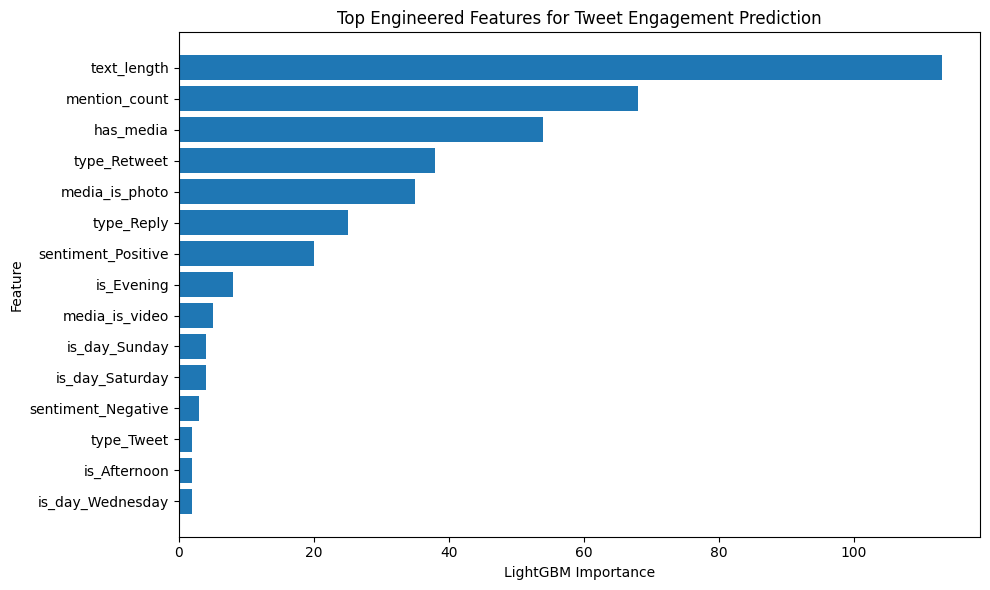

In [65]:
import matplotlib.pyplot as plt

top_features = engineered_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.xlabel("LightGBM Importance")
plt.ylabel("Feature")
plt.title("Top Engineered Features for Tweet Engagement Prediction")
plt.tight_layout()
plt.show()

In [66]:
bert_columns = [
    col for col in X_raw.columns
    if str(col).isdigit()
]

bert_importance = importance_df[
    importance_df["feature"].isin(bert_columns)
]["importance"].sum()

engineered_importance_total = importance_df[
    importance_df["feature"].isin(engineered_features)
]["importance"].sum()

importance_summary = pd.DataFrame({
    "Feature Group": ["mBERT Embeddings", "Engineered Features"],
    "Total Importance": [
        bert_importance,
        engineered_importance_total
    ]
})

display(importance_summary)

,Feature Group,Total Importance
0,mBERT Embeddings,7413
1,Engineered Features,387
